# Bayesian Machine Learning Basics

This notebook introduces **Bayesian machine learning** - a probabilistic framework that treats model parameters as random variables with distributions rather than fixed unknown values.

## Why Bayesian ML?

| Frequentist Approach | Bayesian Approach |
|---------------------|-------------------|
| Parameters are fixed, unknown constants | Parameters are random variables with distributions |
| Point estimates (single "best" value) | Full posterior distributions |
| Confidence intervals (frequentist interpretation) | Credible intervals (direct probability statements) |
| No natural way to incorporate prior knowledge | Prior distributions encode beliefs |
| Uncertainty from sampling variability | Uncertainty from parameter distributions |

## What You'll Learn

1. **Bayes' Theorem** - The mathematical foundation
2. **Priors** - Encoding beliefs before seeing data
3. **Likelihood** - How data informs our beliefs
4. **Posteriors** - Updated beliefs after seeing data
5. **Conjugate Priors** - Analytical solutions when prior and posterior have same form
6. **Uncertainty Quantification** - Credible intervals and predictive distributions
7. **Bayesian Linear Regression** - Full implementation from scratch
8. **When to Use Bayesian Methods** - Practical considerations

## Prerequisites

- Probability distributions (Normal, Beta, Gamma)
- Basic calculus (integration concepts)
- Linear regression fundamentals


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_func, beta as beta_func
np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 1. Bayes' Theorem: The Foundation

Bayes' theorem tells us how to update our beliefs about parameters $\theta$ after observing data $D$:

$$P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)}$$

Let's break down each term:

| Term | Name | Meaning |
|------|------|---------|
| $P(\theta \| D)$ | **Posterior** | Our updated belief about $\theta$ after seeing data |
| $P(D \| \theta)$ | **Likelihood** | Probability of observing data given parameter value |
| $P(\theta)$ | **Prior** | Our belief about $\theta$ before seeing data |
| $P(D)$ | **Evidence** (Marginal Likelihood) | Normalizing constant = $\int P(D|\theta) P(\theta) d\theta$ |

### The Key Insight

$$\underbrace{P(\theta | D)}_{\text{Posterior}} \propto \underbrace{P(D | \theta)}_{\text{Likelihood}} \times \underbrace{P(\theta)}_{\text{Prior}}$$

**"Posterior is proportional to Likelihood times Prior"**

The evidence $P(D)$ is just a normalizing constant to make the posterior integrate to 1.


## 2. Concrete Example: Estimating a Coin's Bias

**Problem:** We have a coin and want to estimate its probability of landing heads ($\theta$).

### Frequentist Approach
Flip the coin $n$ times, count heads $k$, estimate $\hat{\theta} = k/n$.

- After 10 flips with 7 heads: $\hat{\theta} = 0.7$
- Single point estimate, no distribution

### Bayesian Approach
1. Start with a **prior** belief about $\theta$
2. Observe data (flips)
3. Update to **posterior** distribution over $\theta$
4. Get full distribution of beliefs, not just point estimate


## 3. Priors: Encoding Beliefs Before Data

A **prior** distribution $P(\theta)$ encodes our beliefs about the parameter before seeing any data.

### Types of Priors

| Prior Type | Description | Example |
|------------|-------------|---------|
| **Informative** | Strong beliefs based on domain knowledge | "Most coins are fair" → concentrated around 0.5 |
| **Weakly Informative** | Soft constraints, regularization | "Bias is probably between 0.3 and 0.7" |
| **Non-informative** | Minimal assumptions, let data speak | Uniform distribution over [0, 1] |
| **Conjugate** | Mathematical convenience - posterior has same form as prior | Beta prior for binomial likelihood |

### The Beta Distribution - Perfect for Probabilities

For a probability parameter $\theta \in [0, 1]$, the **Beta distribution** is ideal:

$$\text{Beta}(\theta; \alpha, \beta) = \frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha, \beta)}$$

Where $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ is the Beta function.

**Intuition:** 
- $\alpha - 1$ = "pseudo-count" of prior heads
- $\beta - 1$ = "pseudo-count" of prior tails
- Mean = $\frac{\alpha}{\alpha + \beta}$


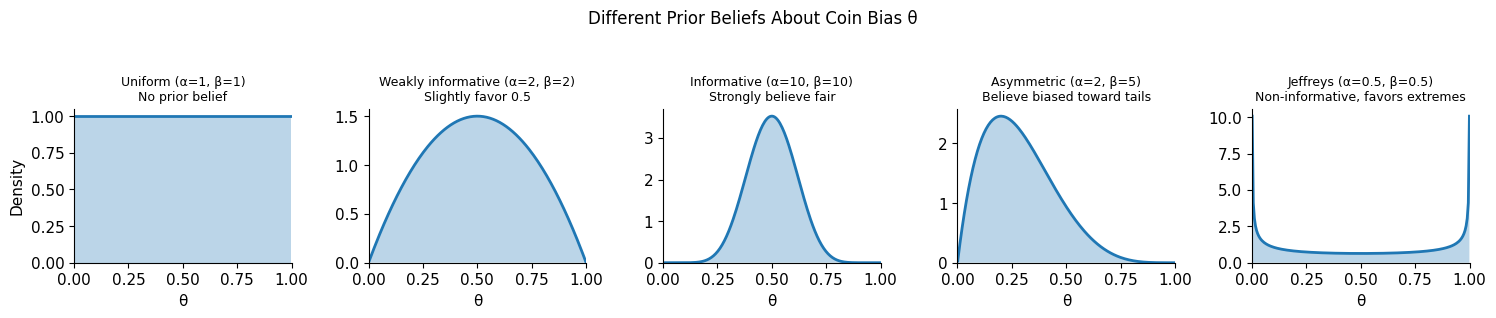

In [2]:
# Visualize different Beta priors
theta = np.linspace(0.001, 0.999, 200)

priors = [
    (1, 1, "Uniform (α=1, β=1)\nNo prior belief"),
    (2, 2, "Weakly informative (α=2, β=2)\nSlightly favor 0.5"),
    (10, 10, "Informative (α=10, β=10)\nStrongly believe fair"),
    (2, 5, "Asymmetric (α=2, β=5)\nBelieve biased toward tails"),
    (0.5, 0.5, "Jeffreys (α=0.5, β=0.5)\nNon-informative, favors extremes"),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, (a, b, title) in zip(axes, priors):
    pdf = stats.beta.pdf(theta, a, b)
    ax.fill_between(theta, pdf, alpha=0.3)
    ax.plot(theta, pdf, lw=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('θ')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, None)

axes[0].set_ylabel('Density')
plt.suptitle('Different Prior Beliefs About Coin Bias θ', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()


## 4. Likelihood: How Data Informs Us

The **likelihood** $P(D|\theta)$ tells us how probable the observed data is for each possible parameter value.

### Binomial Likelihood for Coin Flips

If we flip a coin $n$ times and observe $k$ heads:

$$P(D|\theta) = \binom{n}{k} \theta^k (1-\theta)^{n-k}$$

**Key insight:** The likelihood is NOT a probability distribution over $\theta$. It's a function that tells us how well each $\theta$ value explains the data.

- If we observe 7 heads in 10 flips, $\theta = 0.7$ gives higher likelihood than $\theta = 0.3$
- The likelihood "peaks" at the Maximum Likelihood Estimate (MLE): $\hat{\theta}_{MLE} = k/n$


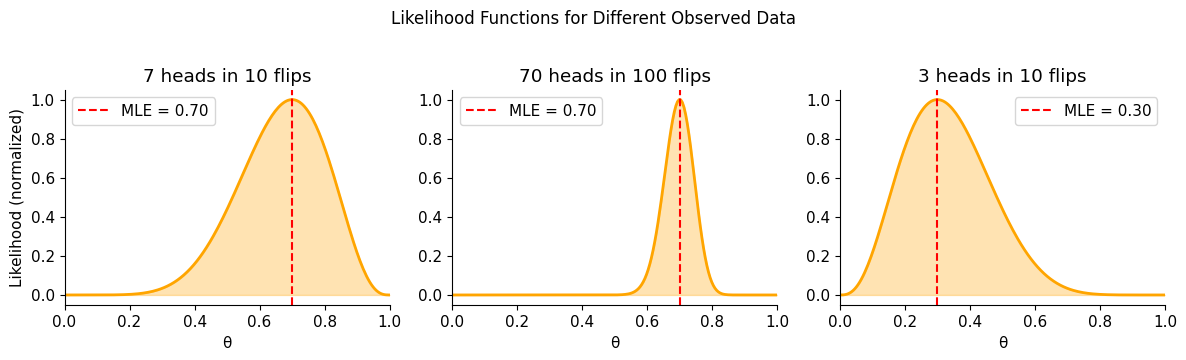

Notice: More data (middle) → narrower likelihood → more certainty about θ


In [3]:
# Visualize likelihood for different data
theta = np.linspace(0.001, 0.999, 200)

def binomial_likelihood(theta, k, n):
    """Likelihood of observing k heads in n flips given bias theta"""
    return stats.binom.pmf(k, n, theta)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Different observed data
data_scenarios = [
    (7, 10, "7 heads in 10 flips"),
    (70, 100, "70 heads in 100 flips"),
    (3, 10, "3 heads in 10 flips"),
]

for ax, (k, n, title) in zip(axes, data_scenarios):
    likelihood = binomial_likelihood(theta, k, n)
    # Normalize for visualization (not a probability distribution!)
    likelihood_normalized = likelihood / likelihood.max()
    
    ax.fill_between(theta, likelihood_normalized, alpha=0.3, color='orange')
    ax.plot(theta, likelihood_normalized, lw=2, color='orange')
    ax.axvline(k/n, color='red', ls='--', label=f'MLE = {k/n:.2f}')
    ax.set_title(title)
    ax.set_xlabel('θ')
    ax.set_xlim(0, 1)
    ax.legend()

axes[0].set_ylabel('Likelihood (normalized)')
plt.suptitle('Likelihood Functions for Different Observed Data', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Notice: More data (middle) → narrower likelihood → more certainty about θ")


## 5. Posterior: Updated Beliefs After Data

The **posterior** combines our prior beliefs with the evidence from data.

### Beta-Binomial Conjugacy (The Beautiful Case)

When we use a **Beta prior** with a **Binomial likelihood**, something magical happens - the posterior is also a Beta distribution!

**Prior:** $\theta \sim \text{Beta}(\alpha, \beta)$

**Data:** $k$ heads in $n$ flips

**Posterior:** $\theta | D \sim \text{Beta}(\alpha + k, \beta + n - k)$

This is called **conjugacy** - the posterior has the same functional form as the prior.

### Intuition

$$\text{Beta}(\underbrace{\alpha + k}_{\text{prior heads + observed heads}}, \underbrace{\beta + (n-k)}_{\text{prior tails + observed tails}})$$

The posterior simply adds the observed counts to our "pseudo-counts" from the prior!


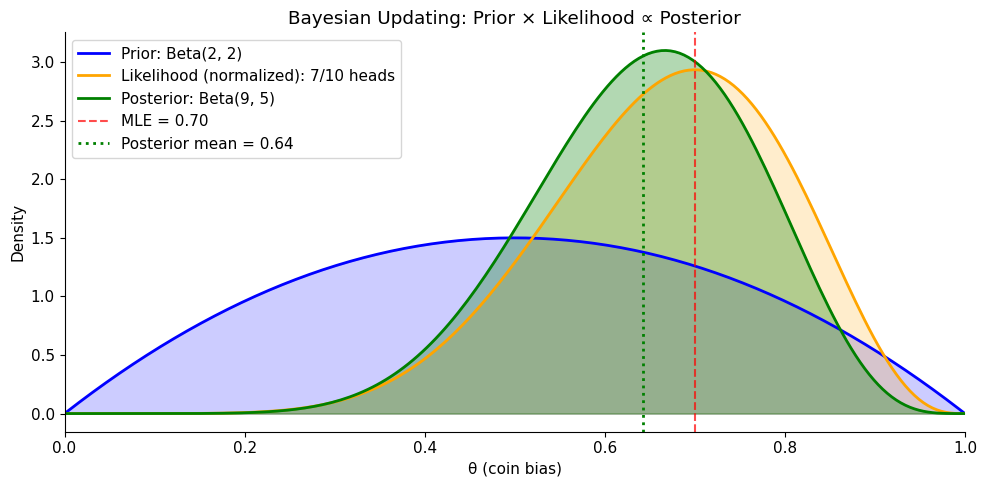

Prior mean: 0.500
MLE (data alone): 0.700
Posterior mean: 0.643 (compromise between prior and data)


In [4]:
# Bayesian updating: Prior → Posterior
theta = np.linspace(0.001, 0.999, 200)

# Prior parameters (weakly informative, slightly favoring fair coin)
alpha_prior, beta_prior = 2, 2

# Observed data: 7 heads in 10 flips
k, n = 7, 10

# Posterior parameters (conjugate update)
alpha_post = alpha_prior + k
beta_post = beta_prior + (n - k)

# Calculate distributions
prior = stats.beta.pdf(theta, alpha_prior, beta_prior)
likelihood = binomial_likelihood(theta, k, n)
likelihood_normalized = likelihood / np.trapezoid(likelihood, theta)  # Normalize for comparison
posterior = stats.beta.pdf(theta, alpha_post, beta_post)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(theta, prior, alpha=0.2, color='blue')
ax.plot(theta, prior, lw=2, color='blue', label=f'Prior: Beta({alpha_prior}, {beta_prior})')

ax.fill_between(theta, likelihood_normalized, alpha=0.2, color='orange')
ax.plot(theta, likelihood_normalized, lw=2, color='orange', label=f'Likelihood (normalized): {k}/{n} heads')

ax.fill_between(theta, posterior, alpha=0.3, color='green')
ax.plot(theta, posterior, lw=2, color='green', label=f'Posterior: Beta({alpha_post}, {beta_post})')

ax.axvline(k/n, color='red', ls='--', alpha=0.7, label=f'MLE = {k/n:.2f}')
ax.axvline(alpha_post/(alpha_post+beta_post), color='green', ls=':', lw=2, 
           label=f'Posterior mean = {alpha_post/(alpha_post+beta_post):.2f}')

ax.set_xlabel('θ (coin bias)')
ax.set_ylabel('Density')
ax.set_title('Bayesian Updating: Prior × Likelihood ∝ Posterior')
ax.legend(loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"Prior mean: {alpha_prior/(alpha_prior+beta_prior):.3f}")
print(f"MLE (data alone): {k/n:.3f}")
print(f"Posterior mean: {alpha_post/(alpha_post+beta_post):.3f} (compromise between prior and data)")


### Sequential Bayesian Updating

One of the beautiful properties of Bayesian inference: **today's posterior becomes tomorrow's prior**.

We can update our beliefs incrementally as new data arrives.


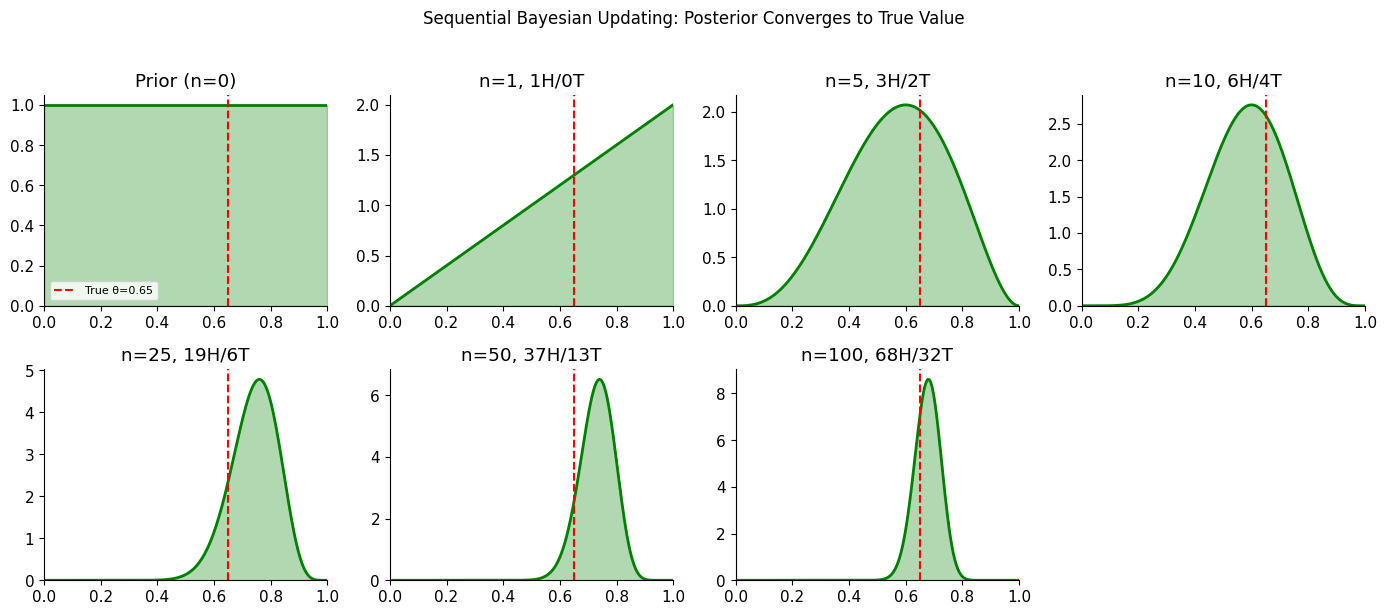

As we see more data, the posterior:
1. Becomes more concentrated (less uncertainty)
2. Centers on the true parameter value (consistency)


In [5]:
# Sequential Bayesian updating - watch beliefs evolve with data
np.random.seed(42)
theta = np.linspace(0.001, 0.999, 200)

# True coin bias (unknown to us)
true_theta = 0.65

# Generate coin flips
n_flips = 100
flips = np.random.binomial(1, true_theta, n_flips)

# Start with uniform prior
alpha, beta = 1, 1

# Checkpoints to visualize
checkpoints = [0, 1, 5, 10, 25, 50, 100]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for idx, n in enumerate(checkpoints):
    ax = axes[idx]
    
    if n == 0:
        # Just the prior
        posterior = stats.beta.pdf(theta, alpha, beta)
        title = f"Prior (n=0)"
    else:
        # Update with data seen so far
        heads = flips[:n].sum()
        tails = n - heads
        alpha_post = alpha + heads
        beta_post = beta + tails
        posterior = stats.beta.pdf(theta, alpha_post, beta_post)
        title = f"n={n}, {heads}H/{tails}T"
    
    ax.fill_between(theta, posterior, alpha=0.3, color='green')
    ax.plot(theta, posterior, lw=2, color='green')
    ax.axvline(true_theta, color='red', ls='--', label=f'True θ={true_theta}')
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, None)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide extra subplot
axes[-1].axis('off')

plt.suptitle('Sequential Bayesian Updating: Posterior Converges to True Value', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("As we see more data, the posterior:")
print("1. Becomes more concentrated (less uncertainty)")
print("2. Centers on the true parameter value (consistency)")


## 6. Uncertainty Quantification

The key advantage of Bayesian methods: **natural uncertainty quantification**.

### Credible Intervals

A **95% credible interval** contains 95% of the posterior probability mass.

Unlike frequentist confidence intervals, we can directly say: *"There is a 95% probability that θ lies in this interval"* (given our model and data).

### Types of Credible Intervals

| Type | Definition | Properties |
|------|------------|------------|
| **Equal-tailed** | 2.5% probability in each tail | Simple, most common |
| **Highest Density Interval (HDI)** | Shortest interval containing 95% | Every point inside has higher density than outside |


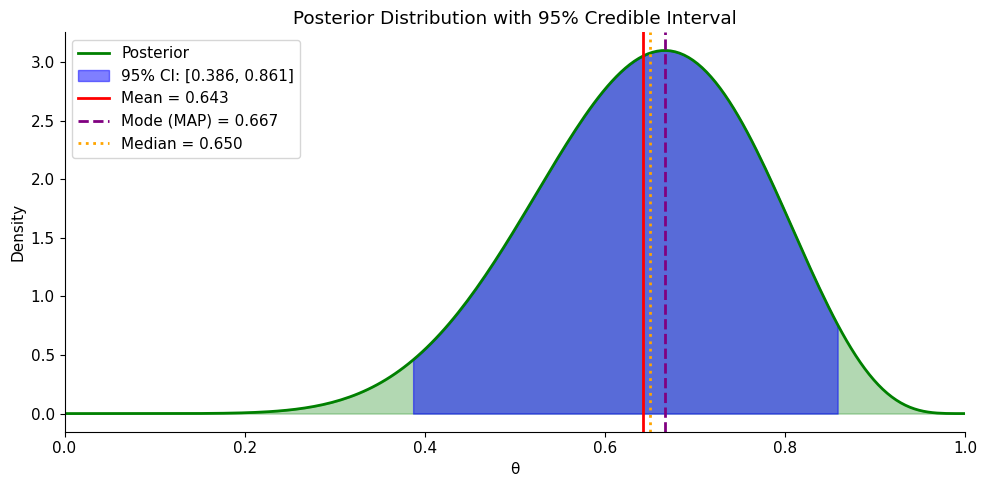


Posterior Summary (Beta(9, 5)):
  Mean:   0.6429
  Median: 0.6498
  Mode:   0.6667
  95% CI: [0.3857, 0.8614]

Interpretation: Given our prior and data, there's a 95% probability
that the true coin bias is between 0.39 and 0.86.


In [6]:
# Credible intervals from our posterior
alpha_post, beta_post = 9, 5  # From earlier: 7 heads in 10 flips with Beta(2,2) prior

theta = np.linspace(0.001, 0.999, 200)
posterior = stats.beta.pdf(theta, alpha_post, beta_post)

# Equal-tailed 95% credible interval
ci_lower = stats.beta.ppf(0.025, alpha_post, beta_post)
ci_upper = stats.beta.ppf(0.975, alpha_post, beta_post)

# Point estimates
posterior_mean = alpha_post / (alpha_post + beta_post)
posterior_mode = (alpha_post - 1) / (alpha_post + beta_post - 2)  # MAP estimate
posterior_median = stats.beta.ppf(0.5, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot posterior
ax.fill_between(theta, posterior, alpha=0.3, color='green')
ax.plot(theta, posterior, lw=2, color='green', label='Posterior')

# Shade credible interval
mask = (theta >= ci_lower) & (theta <= ci_upper)
ax.fill_between(theta[mask], posterior[mask], alpha=0.5, color='blue', 
                label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')

# Point estimates
ax.axvline(posterior_mean, color='red', ls='-', lw=2, label=f'Mean = {posterior_mean:.3f}')
ax.axvline(posterior_mode, color='purple', ls='--', lw=2, label=f'Mode (MAP) = {posterior_mode:.3f}')
ax.axvline(posterior_median, color='orange', ls=':', lw=2, label=f'Median = {posterior_median:.3f}')

ax.set_xlabel('θ')
ax.set_ylabel('Density')
ax.set_title('Posterior Distribution with 95% Credible Interval')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nPosterior Summary (Beta({alpha_post}, {beta_post})):")
print(f"  Mean:   {posterior_mean:.4f}")
print(f"  Median: {posterior_median:.4f}")
print(f"  Mode:   {posterior_mode:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nInterpretation: Given our prior and data, there's a 95% probability")
print(f"that the true coin bias is between {ci_lower:.2f} and {ci_upper:.2f}.")


## 7. Common Conjugate Priors

Conjugate priors give us analytical posteriors (no numerical integration needed).

| Likelihood | Conjugate Prior | Posterior | Use Case |
|------------|-----------------|-----------|----------|
| **Binomial** | Beta | Beta | Coin flips, click-through rates |
| **Poisson** | Gamma | Gamma | Event counts, arrivals |
| **Normal** (known σ²) | Normal | Normal | Continuous measurements |
| **Normal** (unknown σ²) | Normal-Inverse-Gamma | Normal-Inverse-Gamma | Measurements with unknown variance |
| **Multinomial** | Dirichlet | Dirichlet | Category probabilities |
| **Exponential** | Gamma | Gamma | Waiting times |

### Example: Normal-Normal Conjugacy

For data $x_1, ..., x_n \sim \mathcal{N}(\mu, \sigma^2)$ with **known** variance $\sigma^2$:

- **Prior:** $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$
- **Posterior:** $\mu | D \sim \mathcal{N}(\mu_n, \sigma_n^2)$

Where:
$$\mu_n = \frac{\frac{1}{\sigma_0^2}\mu_0 + \frac{n}{\sigma^2}\bar{x}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}, \quad \sigma_n^2 = \frac{1}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

The posterior mean is a **precision-weighted average** of prior mean and sample mean!


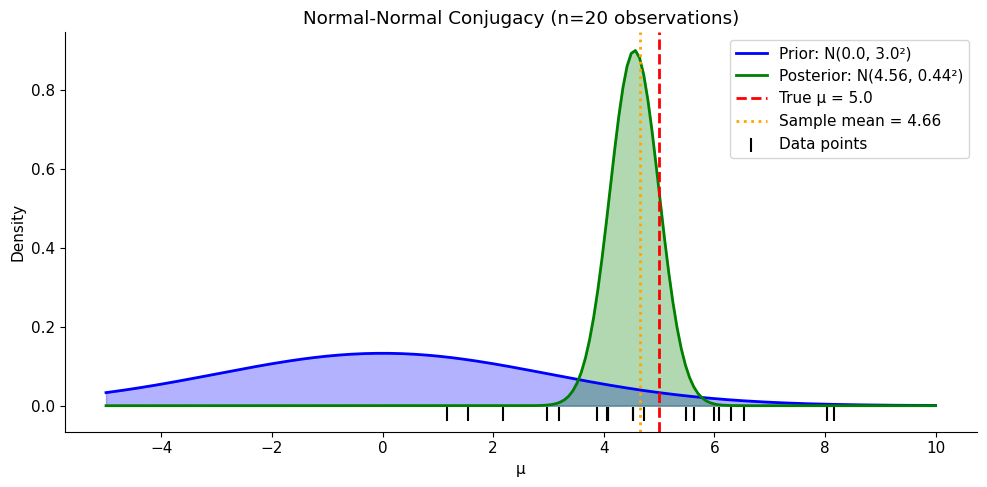

Prior mean: 0.00
Sample mean (MLE): 4.66
Posterior mean: 4.56 (shrunk toward prior)
Posterior std: 0.44 (reduced uncertainty)


In [7]:
# Normal-Normal conjugacy example
np.random.seed(42)

# True parameters (unknown to us)
true_mu = 5.0
sigma = 2.0  # Known variance

# Prior on mu
mu_0 = 0.0      # Prior mean
sigma_0 = 3.0   # Prior std

# Generate data
n_samples = 20
data = np.random.normal(true_mu, sigma, n_samples)
sample_mean = data.mean()

# Posterior parameters (conjugate update)
precision_prior = 1 / sigma_0**2
precision_data = n_samples / sigma**2

sigma_n_sq = 1 / (precision_prior + precision_data)
mu_n = sigma_n_sq * (precision_prior * mu_0 + precision_data * sample_mean)
sigma_n = np.sqrt(sigma_n_sq)

# Visualize
mu_range = np.linspace(-5, 10, 200)

prior = stats.norm.pdf(mu_range, mu_0, sigma_0)
posterior = stats.norm.pdf(mu_range, mu_n, sigma_n)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(mu_range, prior, alpha=0.3, color='blue')
ax.plot(mu_range, prior, lw=2, color='blue', label=f'Prior: N({mu_0}, {sigma_0}²)')

ax.fill_between(mu_range, posterior, alpha=0.3, color='green')
ax.plot(mu_range, posterior, lw=2, color='green', label=f'Posterior: N({mu_n:.2f}, {sigma_n:.2f}²)')

ax.axvline(true_mu, color='red', ls='--', lw=2, label=f'True μ = {true_mu}')
ax.axvline(sample_mean, color='orange', ls=':', lw=2, label=f'Sample mean = {sample_mean:.2f}')

ax.scatter(data, np.zeros_like(data) - 0.02, marker='|', s=100, color='black', label='Data points')

ax.set_xlabel('μ')
ax.set_ylabel('Density')
ax.set_title(f'Normal-Normal Conjugacy (n={n_samples} observations)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prior mean: {mu_0:.2f}")
print(f"Sample mean (MLE): {sample_mean:.2f}")
print(f"Posterior mean: {mu_n:.2f} (shrunk toward prior)")
print(f"Posterior std: {sigma_n:.2f} (reduced uncertainty)")


## 8. Bayesian Linear Regression

Now let's apply Bayesian inference to a real ML problem: linear regression.

### Frequentist Linear Regression

**Model:** $y = X\mathbf{w} + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2)$

**Goal:** Find single "best" weights $\hat{\mathbf{w}}$

**Solution:** $\hat{\mathbf{w}}_{OLS} = (X^TX)^{-1}X^T\mathbf{y}$

### Bayesian Linear Regression

**Model:** Same, but treat $\mathbf{w}$ as random

**Prior:** $\mathbf{w} \sim \mathcal{N}(\mathbf{m}_0, S_0)$

**Likelihood:** $P(\mathbf{y}|X, \mathbf{w}) = \mathcal{N}(X\mathbf{w}, \sigma^2 I)$

**Posterior:** $\mathbf{w}|D \sim \mathcal{N}(\mathbf{m}_n, S_n)$

Where (for known $\sigma^2$):
$$S_n = \left(S_0^{-1} + \frac{1}{\sigma^2}X^TX\right)^{-1}$$
$$\mathbf{m}_n = S_n\left(S_0^{-1}\mathbf{m}_0 + \frac{1}{\sigma^2}X^T\mathbf{y}\right)$$

### Key Insight: Prior = Regularization!

With a zero-mean isotropic prior $\mathbf{w} \sim \mathcal{N}(0, \tau^2 I)$:
- The posterior mean equals the **Ridge regression** solution!
- $\lambda = \sigma^2/\tau^2$ is the regularization strength
- Bayesian inference gives a probabilistic interpretation to regularization


In [8]:
class BayesianLinearRegression:
    """Bayesian Linear Regression with Gaussian prior."""
    
    def __init__(self, prior_mean=None, prior_cov=None, noise_var=1.0):
        """
        Args:
            prior_mean: Prior mean for weights (default: zeros)
            prior_cov: Prior covariance for weights (default: identity)
            noise_var: Known noise variance σ²
        """
        self.prior_mean = prior_mean
        self.prior_cov = prior_cov
        self.noise_var = noise_var
        self.posterior_mean = None
        self.posterior_cov = None
        
    def fit(self, X, y):
        """Compute posterior distribution over weights."""
        n_features = X.shape[1]
        
        # Default prior: zero mean, identity covariance
        if self.prior_mean is None:
            self.prior_mean = np.zeros(n_features)
        if self.prior_cov is None:
            self.prior_cov = np.eye(n_features)
        
        # Posterior covariance
        prior_precision = np.linalg.inv(self.prior_cov)
        data_precision = (1 / self.noise_var) * X.T @ X
        self.posterior_cov = np.linalg.inv(prior_precision + data_precision)
        
        # Posterior mean
        self.posterior_mean = self.posterior_cov @ (
            prior_precision @ self.prior_mean + 
            (1 / self.noise_var) * X.T @ y
        )
        
        return self
    
    def predict(self, X, return_std=False):
        """Predict with uncertainty quantification."""
        # Predictive mean
        y_mean = X @ self.posterior_mean
        
        if return_std:
            # Predictive variance = noise + parameter uncertainty
            y_var = self.noise_var + np.sum(X @ self.posterior_cov * X, axis=1)
            return y_mean, np.sqrt(y_var)
        return y_mean
    
    def sample_weights(self, n_samples=100):
        """Sample weight vectors from posterior."""
        return np.random.multivariate_normal(
            self.posterior_mean, self.posterior_cov, n_samples
        )

print("BayesianLinearRegression class defined!")


BayesianLinearRegression class defined!


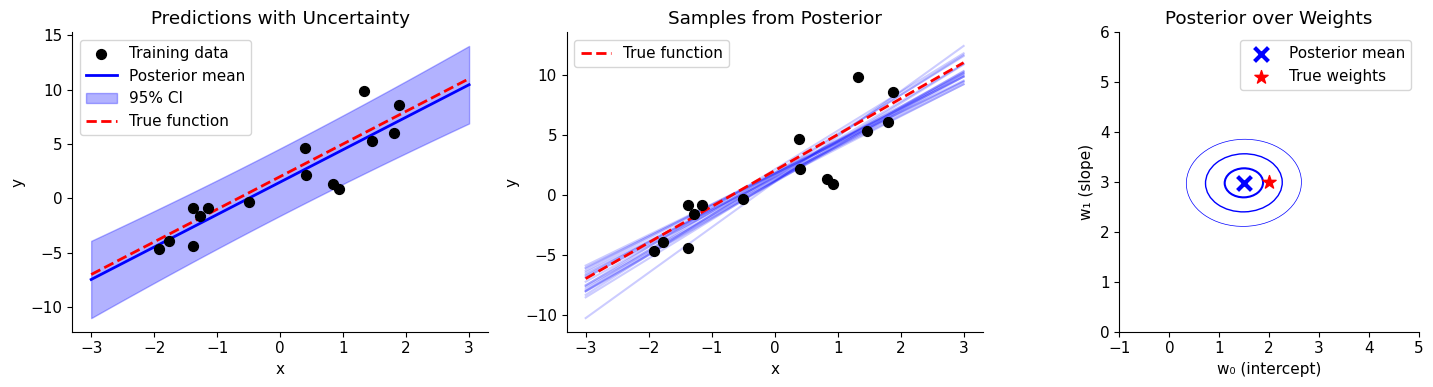


True weights: w₀=2.0, w₁=3.0
Posterior mean: w₀=1.494, w₁=2.984
Posterior std: w₀=0.384, w₁=0.291


In [9]:
# Generate synthetic data
np.random.seed(42)

# True function: y = 2 + 3x + noise
true_w0, true_w1 = 2.0, 3.0
noise_std = 1.5

n_train = 15
X_train = np.random.uniform(-2, 2, n_train)
y_train = true_w0 + true_w1 * X_train + np.random.normal(0, noise_std, n_train)

# Design matrix with bias term
X_design = np.column_stack([np.ones_like(X_train), X_train])

# Fit Bayesian Linear Regression
blr = BayesianLinearRegression(
    prior_cov=10.0 * np.eye(2),  # Weak prior
    noise_var=noise_std**2
)
blr.fit(X_design, y_train)

# Predictions on dense grid
X_test = np.linspace(-3, 3, 100)
X_test_design = np.column_stack([np.ones_like(X_test), X_test])
y_pred, y_std = blr.predict(X_test_design, return_std=True)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Data and predictions with uncertainty
ax = axes[0]
ax.scatter(X_train, y_train, c='black', s=50, zorder=5, label='Training data')
ax.plot(X_test, y_pred, 'b-', lw=2, label='Posterior mean')
ax.fill_between(X_test, y_pred - 2*y_std, y_pred + 2*y_std, 
                alpha=0.3, color='blue', label='95% CI')
ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2, label='True function')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Predictions with Uncertainty')
ax.legend()

# Plot 2: Sample functions from posterior
ax = axes[1]
ax.scatter(X_train, y_train, c='black', s=50, zorder=5)
weight_samples = blr.sample_weights(20)
for w in weight_samples:
    y_sample = X_test_design @ w
    ax.plot(X_test, y_sample, 'b-', alpha=0.2)
ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2, label='True function')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Samples from Posterior')
ax.legend()

# Plot 3: Posterior over weights
ax = axes[2]
from matplotlib.patches import Ellipse

# Plot posterior as 2D Gaussian
mean = blr.posterior_mean
cov = blr.posterior_cov

# Eigendecomposition for ellipse
eigenvalues, eigenvectors = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

for n_std in [1, 2, 3]:
    ellipse = Ellipse(mean, width=2*n_std*np.sqrt(eigenvalues[0]), 
                      height=2*n_std*np.sqrt(eigenvalues[1]),
                      angle=angle, fill=False, color='blue', lw=2-n_std*0.5)
    ax.add_patch(ellipse)

ax.scatter(*mean, c='blue', s=100, marker='x', lw=3, label='Posterior mean')
ax.scatter(true_w0, true_w1, c='red', s=100, marker='*', label='True weights')
ax.set_xlabel('w₀ (intercept)')
ax.set_ylabel('w₁ (slope)')
ax.set_title('Posterior over Weights')
ax.legend()
ax.set_aspect('equal')
ax.set_xlim(-1, 5)
ax.set_ylim(0, 6)

plt.tight_layout()
plt.show()

print(f"\nTrue weights: w₀={true_w0}, w₁={true_w1}")
print(f"Posterior mean: w₀={blr.posterior_mean[0]:.3f}, w₁={blr.posterior_mean[1]:.3f}")
print(f"Posterior std: w₀={np.sqrt(blr.posterior_cov[0,0]):.3f}, w₁={np.sqrt(blr.posterior_cov[1,1]):.3f}")


### Key Observations

1. **Uncertainty grows away from data**: The confidence bands widen where we have fewer observations
2. **Multiple plausible functions**: Sampling from the posterior shows the range of functions consistent with our beliefs
3. **Posterior captures parameter uncertainty**: The ellipse shows correlation and uncertainty in weights

### Sequential Updating with More Data


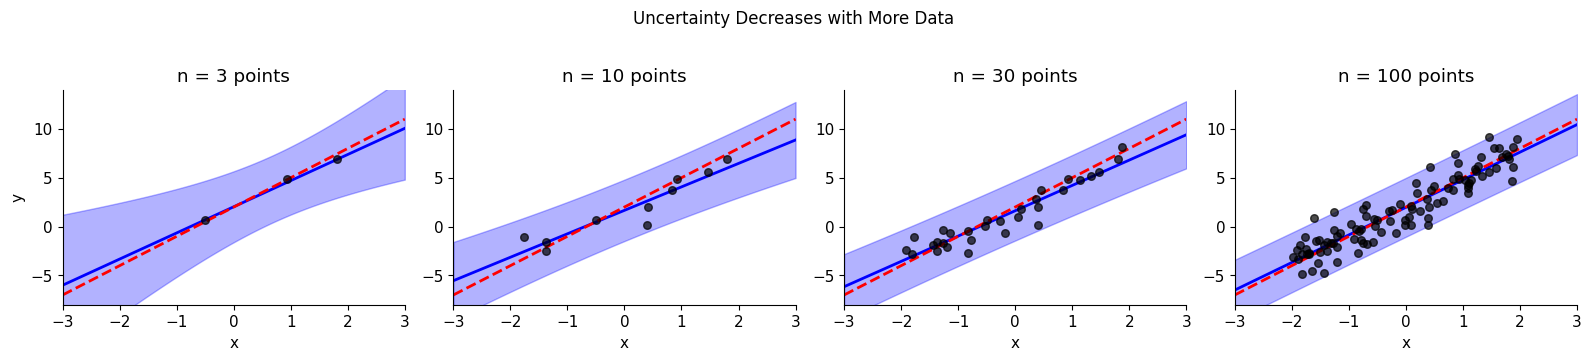

More data → narrower confidence bands → more certainty in predictions


In [10]:
# Show how uncertainty decreases with more data
np.random.seed(42)

# Generate more data
n_total = 100
X_all = np.random.uniform(-2, 2, n_total)
y_all = true_w0 + true_w1 * X_all + np.random.normal(0, noise_std, n_total)

data_sizes = [3, 10, 30, 100]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, n in zip(axes, data_sizes):
    # Use first n points
    X_n = X_all[:n]
    y_n = y_all[:n]
    X_design_n = np.column_stack([np.ones(n), X_n])
    
    # Fit
    blr_n = BayesianLinearRegression(prior_cov=10.0 * np.eye(2), noise_var=noise_std**2)
    blr_n.fit(X_design_n, y_n)
    
    # Predict
    y_pred_n, y_std_n = blr_n.predict(X_test_design, return_std=True)
    
    # Plot
    ax.scatter(X_n, y_n, c='black', s=30, zorder=5, alpha=0.7)
    ax.plot(X_test, y_pred_n, 'b-', lw=2)
    ax.fill_between(X_test, y_pred_n - 2*y_std_n, y_pred_n + 2*y_std_n, 
                    alpha=0.3, color='blue')
    ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2)
    ax.set_title(f'n = {n} points')
    ax.set_xlabel('x')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-8, 14)

axes[0].set_ylabel('y')
plt.suptitle('Uncertainty Decreases with More Data', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("More data → narrower confidence bands → more certainty in predictions")


## 9. Predictive Distribution

The **posterior predictive distribution** is what we ultimately care about: the distribution of predictions for new inputs.

$$P(y^* | x^*, D) = \int P(y^* | x^*, \mathbf{w}) P(\mathbf{w} | D) d\mathbf{w}$$

This integrates out the parameter uncertainty:
- We don't just predict with the "best" weights
- We average predictions over all plausible weight values, weighted by their posterior probability

### Two Sources of Uncertainty

1. **Epistemic uncertainty** (parameter uncertainty): What are the true weights? Decreases with more data.
2. **Aleatoric uncertainty** (noise): Inherent randomness in the data. Does not decrease with more data.


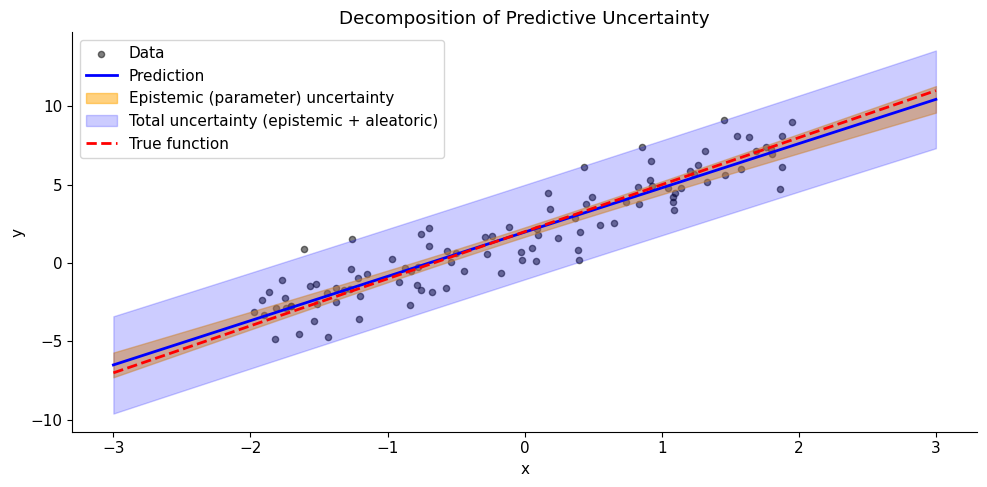

Aleatoric uncertainty (noise): 1.500 (constant)
Epistemic uncertainty at x=0: 0.151
Epistemic uncertainty at x=3: 0.422 (higher away from data)


In [11]:
# Decompose uncertainty into epistemic and aleatoric
X_design_full = np.column_stack([np.ones(n_total), X_all])
blr_full = BayesianLinearRegression(prior_cov=10.0 * np.eye(2), noise_var=noise_std**2)
blr_full.fit(X_design_full, y_all)

# Compute uncertainty components
y_pred_full, y_std_full = blr_full.predict(X_test_design, return_std=True)

# Epistemic uncertainty (parameter uncertainty only)
epistemic_var = np.sum(X_test_design @ blr_full.posterior_cov * X_test_design, axis=1)
epistemic_std = np.sqrt(epistemic_var)

# Aleatoric uncertainty (noise)
aleatoric_std = noise_std * np.ones_like(X_test)

# Total uncertainty
total_var = epistemic_var + noise_std**2
total_std = np.sqrt(total_var)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(X_all, y_all, c='black', s=20, alpha=0.5, label='Data')
ax.plot(X_test, y_pred_full, 'b-', lw=2, label='Prediction')

# Show both uncertainty types
ax.fill_between(X_test, y_pred_full - 2*epistemic_std, y_pred_full + 2*epistemic_std, 
                alpha=0.5, color='orange', label='Epistemic (parameter) uncertainty')
ax.fill_between(X_test, y_pred_full - 2*total_std, y_pred_full + 2*total_std, 
                alpha=0.2, color='blue', label='Total uncertainty (epistemic + aleatoric)')

ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2, label='True function')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Decomposition of Predictive Uncertainty')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Aleatoric uncertainty (noise): {aleatoric_std[0]:.3f} (constant)")
print(f"Epistemic uncertainty at x=0: {epistemic_std[50]:.3f}")
print(f"Epistemic uncertainty at x=3: {epistemic_std[-1]:.3f} (higher away from data)")


## 10. Bayesian vs Frequentist: Key Differences

| Aspect | Frequentist | Bayesian |
|--------|-------------|----------|
| **Parameters** | Fixed unknown constants | Random variables with distributions |
| **Probability** | Long-run frequency | Degree of belief |
| **Inference** | Point estimates (MLE) | Full posterior distributions |
| **Uncertainty** | Confidence intervals | Credible intervals |
| **Prior information** | Cannot incorporate | Naturally incorporated |
| **Small data** | Can be unreliable | Prior helps regularize |
| **Interpretation** | "95% of intervals contain true value" | "95% probability true value is in interval" |
| **Computation** | Usually analytical/fast | Often requires MCMC/variational methods |

### When to Use Bayesian Methods

✅ **Use Bayesian when:**
- You have prior knowledge to incorporate
- Uncertainty quantification is critical
- You have small datasets
- You need to make decisions under uncertainty
- Interpretability of uncertainty matters

❌ **Consider alternatives when:**
- Computational cost is prohibitive
- You have massive datasets (prior becomes irrelevant)
- You only need point predictions
- The model is very complex (posterior intractable)


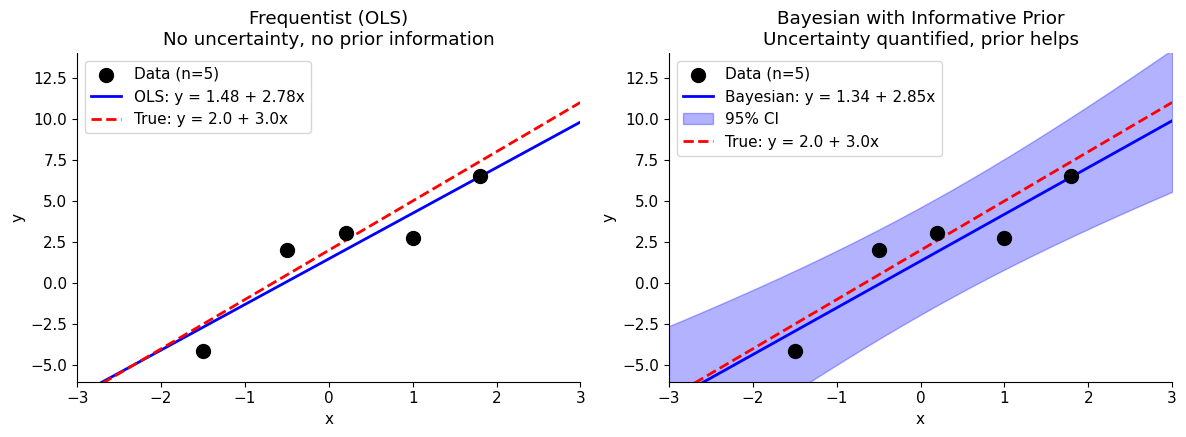


With only 5 data points:
  OLS slope: 2.776
  Bayesian slope: 2.847
  True slope: 3.0

The Bayesian estimate is pulled toward the prior (slope=3), regularizing the estimate.


In [12]:
# Compare Bayesian vs OLS on small dataset
np.random.seed(123)

# Small dataset - where Bayesian shines
n_small = 5
X_small = np.array([-1.5, -0.5, 0.2, 1.0, 1.8])
y_small = true_w0 + true_w1 * X_small + np.random.normal(0, noise_std, n_small)

X_design_small = np.column_stack([np.ones(n_small), X_small])

# OLS (frequentist)
w_ols = np.linalg.lstsq(X_design_small, y_small, rcond=None)[0]
y_ols = X_test_design @ w_ols

# Bayesian with informative prior (we believe slope is around 3)
prior_mean = np.array([0, 3])  # Prior: intercept~0, slope~3
prior_cov = np.diag([5, 1])    # More certain about slope

blr_informed = BayesianLinearRegression(
    prior_mean=prior_mean, 
    prior_cov=prior_cov, 
    noise_var=noise_std**2
)
blr_informed.fit(X_design_small, y_small)
y_bayes, y_bayes_std = blr_informed.predict(X_test_design, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: OLS
ax = axes[0]
ax.scatter(X_small, y_small, c='black', s=100, zorder=5, label='Data (n=5)')
ax.plot(X_test, y_ols, 'b-', lw=2, label=f'OLS: y = {w_ols[0]:.2f} + {w_ols[1]:.2f}x')
ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2, label=f'True: y = {true_w0} + {true_w1}x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Frequentist (OLS)\nNo uncertainty, no prior information')
ax.legend()
ax.set_xlim(-3, 3)
ax.set_ylim(-6, 14)

# Plot 2: Bayesian
ax = axes[1]
ax.scatter(X_small, y_small, c='black', s=100, zorder=5, label='Data (n=5)')
ax.plot(X_test, y_bayes, 'b-', lw=2, 
        label=f'Bayesian: y = {blr_informed.posterior_mean[0]:.2f} + {blr_informed.posterior_mean[1]:.2f}x')
ax.fill_between(X_test, y_bayes - 2*y_bayes_std, y_bayes + 2*y_bayes_std, 
                alpha=0.3, color='blue', label='95% CI')
ax.plot(X_test, true_w0 + true_w1 * X_test, 'r--', lw=2, label=f'True: y = {true_w0} + {true_w1}x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Bayesian with Informative Prior\nUncertainty quantified, prior helps')
ax.legend()
ax.set_xlim(-3, 3)
ax.set_ylim(-6, 14)

plt.tight_layout()
plt.show()

print(f"\nWith only {n_small} data points:")
print(f"  OLS slope: {w_ols[1]:.3f}")
print(f"  Bayesian slope: {blr_informed.posterior_mean[1]:.3f}")
print(f"  True slope: {true_w1}")
print(f"\nThe Bayesian estimate is pulled toward the prior (slope=3), regularizing the estimate.")


## 11. Beyond Conjugate Priors: Computational Methods

When conjugate priors don't apply (most real-world cases), we need numerical methods:

### Markov Chain Monte Carlo (MCMC)

Sample from the posterior using random walks:
- **Metropolis-Hastings**: Accept/reject proposed samples
- **Gibbs Sampling**: Sample each parameter conditionally
- **Hamiltonian Monte Carlo (HMC)**: Use gradient information for efficient sampling

### Variational Inference

Approximate the posterior with a simpler distribution:
- Faster than MCMC
- Scales to large datasets
- May underestimate uncertainty

### Popular Libraries

| Library | Language | Strengths |
|---------|----------|-----------|
| **PyMC** | Python | User-friendly, MCMC |
| **Stan** | Multi | State-of-the-art HMC |
| **NumPyro** | Python/JAX | Fast, GPU-accelerated |
| **TensorFlow Probability** | Python | Deep learning integration |
| **Pyro** | Python/PyTorch | Deep learning integration |


## Summary

### Key Takeaways

1. **Bayes' Theorem**: Posterior ∝ Likelihood × Prior

2. **Priors** encode beliefs before data:
   - Informative priors incorporate domain knowledge
   - Non-informative priors let data dominate
   - Conjugate priors give analytical posteriors

3. **Posteriors** are updated beliefs after data:
   - Full distributions, not point estimates
   - Automatically balance prior and evidence
   - More data → posterior dominates prior

4. **Uncertainty quantification**:
   - Credible intervals with direct probability interpretation
   - Decompose into epistemic (reducible) and aleatoric (irreducible)
   - Uncertainty increases away from data

5. **Bayesian = Probabilistic Regularization**:
   - Prior acts as regularizer
   - Gaussian prior → Ridge regression
   - Laplace prior → Lasso regression

### Connections to Deep Learning

- **Weight decay** = Gaussian prior on weights
- **Dropout** ≈ Approximate Bayesian inference
- **Bayesian Neural Networks** = Full posterior over weights
- **Uncertainty in predictions** = Critical for safe AI

### Next Steps

- Explore **PyMC** or **NumPyro** for practical Bayesian modeling
- Study **Gaussian Processes** (infinite-dimensional Bayesian regression)
- Learn **Variational Autoencoders** (VAEs) - Bayesian deep learning
- Investigate **Bayesian optimization** for hyperparameter tuning
